<a href="https://colab.research.google.com/github/cu24250113-priyashi/Computer_Vision/blob/main/LabSheet6(CV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LAB SHEET - 6

####PRIYASHI
####B-TECH CSE
####ROLL NO 39

In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from skimage.segmentation import felzenszwalb
from skimage.color import label2rgb
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.segmentation import slic
from skimage.color import label2rgb
from skimage import graph
from skimage.segmentation import active_contour
from skimage.filters import gaussian

In [68]:
image_path = "/content/tiger.jpeg"
img = cv2.imread(image_path, -1)

1. Build a threshold-based segmentation tool with adjustable global and adaptive thresholds.

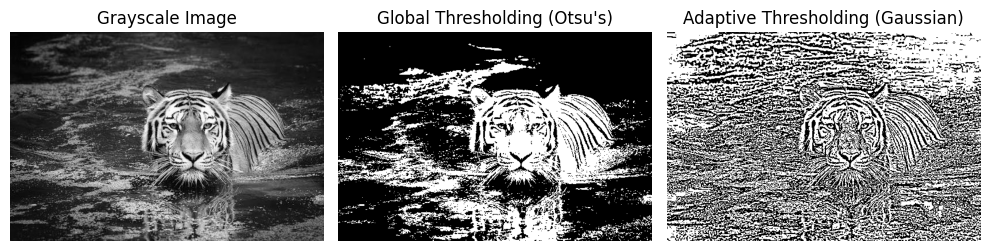

In [70]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
_, thresh_global = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
thresh_adaptive = cv2.adaptiveThreshold(
    gray_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Grayscale Image')
axes[0].axis('off')
axes[1].imshow(thresh_global, cmap='gray')
axes[1].set_title("Global Thresholding (Otsu's)")
axes[1].axis('off')
axes[2].imshow(thresh_adaptive, cmap='gray')
axes[2].set_title('Adaptive Thresholding (Gaussian)')
axes[2].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)

2. Develop a region-growing segmentation tool that segments an image starting from user-selected seed points.

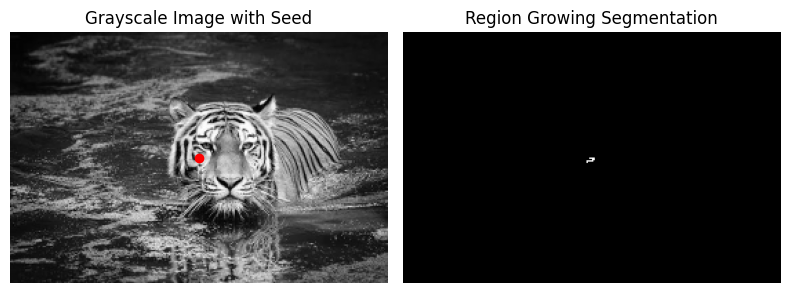

In [29]:
def region_growing(img, seed, threshold=15):
    h, w = img.shape
    segmented = np.zeros((h, w), dtype=np.uint8)
    visited = np.zeros((h, w), dtype=bool)
    seed_y, seed_x = seed
    seed_val = float(img[seed_y, seed_x])
    queue = [(seed_y, seed_x)]
    segmented[seed_y, seed_x] = 255
    visited[seed_y, seed_x] = True
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    while len(queue) > 0:
        curr_y, curr_x = queue.pop(0)
        for dy, dx in neighbors:
            ny, nx = curr_y + dy, curr_x + dx
            if 0 <= ny < h and 0 <= nx < w:
                if not visited[ny, nx]:
                    val = float(img[ny, nx])
                    if abs(val - seed_val) < threshold:
                        segmented[ny, nx] = 255
                        queue.append((ny, nx))
                    visited[ny, nx] = True
    return segmented
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
small_gray = cv2.resize(gray_img, (0,0), fx=0.5, fy=0.5)
seed_pt = (small_gray.shape[0] // 2, small_gray.shape[1] // 2)
segmented_region = region_growing(small_gray, seed_pt, threshold=20)
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(small_gray, cmap='gray')
axes[0].plot(seed_pt[1], seed_pt[0], 'ro')
axes[0].set_title('Grayscale Image with Seed')
axes[0].axis('off')
axes[1].imshow(segmented_region, cmap='gray')
axes[1].set_title('Region Growing Segmentation')
axes[1].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)

3. Create a split-and-merge segmentation demo on a textured or satellite image.

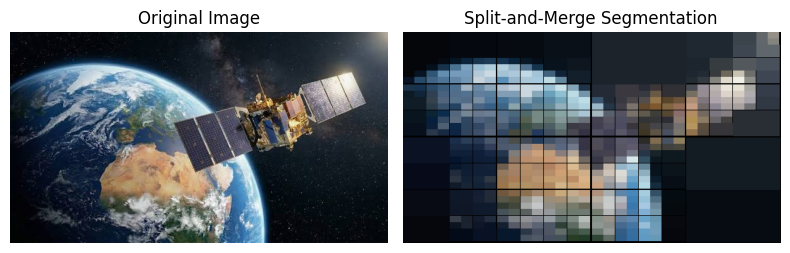

In [30]:
image_path = "/content/satellite.jpeg"
img2 = cv2.imread(image_path, -1)
img_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
class QuadNode:
    def __init__(self, x, y, w, h):
        self.x = x
        self.y = y
        self.w = w
        self.h = h
        self.is_leaf = True
        self.children = []
        self.mean_color = np.array([0.0, 0.0, 0.0])
def check_homogeneity(image, x, y, w, h, threshold=15.0):
    region = image[y:y+h, x:x+w]
    if region.size == 0:
        return True
    std_dev = np.std(region)
    return std_dev < threshold
def split_image(image, node, min_size=8, threshold=15.0):
    region = image[node.y:node.y+node.h, node.x:node.x+node.w]
    if region.size == 0:
        return
    node.mean_color = np.mean(region, axis=(0, 1))
    if node.w > min_size and node.h > min_size and not check_homogeneity(image, node.x, node.y, node.w, node.h, threshold):
        node.is_leaf = False
        hw = node.w // 2
        hh = node.h // 2
        c1 = QuadNode(node.x, node.y, hw, hh)
        c2 = QuadNode(node.x + hw, node.y, hw, hh)
        c3 = QuadNode(node.x, node.y + hh, hw, hh)
        c4 = QuadNode(node.x + hw, node.y + hh, hw, hh)
        node.children = [c1, c2, c3, c4]
        for child in node.children:
            split_image(image, child, min_size, threshold)
def get_segmented_image(node, segmented_img):
    if node.is_leaf:
        segmented_img[node.y:node.y+node.h, node.x:node.x+node.w] = node.mean_color.astype(np.uint8)
    else:
        for child in node.children:
            get_segmented_image(child, segmented_img)
root = QuadNode(0, 0, img_rgb.shape[1], img_rgb.shape[0])
split_image(img_rgb, root, min_size=16, threshold=20.0)
segmented_colored = np.zeros_like(img_rgb)
get_segmented_image(root, segmented_colored)
fig, axes = plt.subplots(1, 2, figsize=(8, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(segmented_colored)
axes[1].set_title('Split-and-Merge Segmentation')
axes[1].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)

4. Build a watershed segmentation tool to seprate touching or overlapping objects(e.g ,coins or cells).

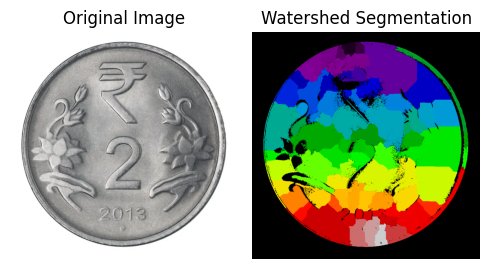

In [43]:
image_path = "/content/coin.webp"
img3 = cv2.imread(image_path, -1)
gray_img = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY) if len(img3.shape) == 3 else img3
_, binary = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
distance = ndi.distance_transform_edt(binary)
coords = peak_local_max(distance, min_distance=20, labels=binary)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels = watershed(-distance, markers, mask=binary)
fig, axes = plt.subplots(1, 2, figsize=(5, 5))
if len(img3.shape) == 3:
    img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
else:
    img3_rgb = img3
axes[0].imshow(img3_rgb, cmap='gray' if len(img3.shape) == 2 else None)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(labels, cmap=plt.cm.nipy_spectral)
axes[1].set_title('Watershed Segmentation')
axes[1].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)

5. Develop a K-means or mean-shift color segmentation tool that clusters images region by color similarity.

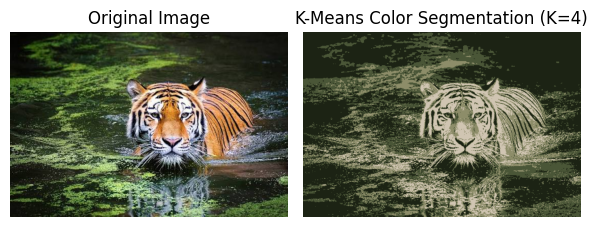

In [46]:
pixel_vals = img.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 4
_, labels, centers = cv2.kmeans(pixel_vals, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_img = segmented_data.reshape((img.shape))
fig, axes = plt.subplots(1, 2, figsize=(6, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'K-Means Color Segmentation (K={K})')
axes[1].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)

6. Create an interactive foreground-extration tool using a graph-based method such as GrabCut.

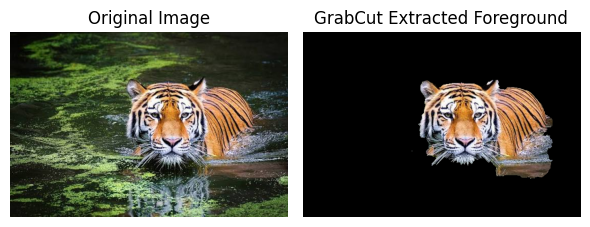

In [48]:
bg_model = np.zeros((1, 65), np.float64)
fg_model = np.zeros((1, 65), np.float64)
h, w, _ = img.shape
rect = (int(w * 0.1), int(h * 0.1), int(w * 0.8), int(h * 0.8))
mask = np.zeros(img.shape[:2], np.uint8)
cv2.grabCut(img, mask, rect, bg_model, fg_model, 5, cv2.GC_INIT_WITH_RECT)
final_mask = np.where((mask == cv2.GC_PR_FGD) | (mask == cv2.GC_FGD), 1, 0).astype('uint8')
foreground = img * final_mask[:, :, np.newaxis]
fig, axes = plt.subplots(1, 2, figsize=(6, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB))
axes[1].set_title('GrabCut Extracted Foreground')
axes[1].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)

7. Build a normalized-cut based segmentation demo that partitions an image into meaningful region.

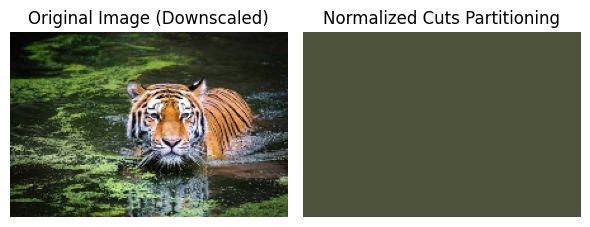

In [71]:
small_img = cv2.resize(img, (0, 0), fx=0.4, fy=0.4)
rgb_small = cv2.cvtColor(small_img, cv2.COLOR_BGR2RGB)
labels1 = slic(rgb_small, compactness=30, n_segments=400, start_label=1)
g = graph.rag_mean_color(rgb_small, labels1)
labels2 = graph.cut_normalized(labels1, g)
out2 = label2rgb(labels2, rgb_small, kind='avg', bg_label=0)
fig, axes = plt.subplots(1, 2, figsize=(6, 6))
axes[0].imshow(rgb_small)
axes[0].set_title('Original Image (Downscaled)')
axes[0].axis('off')
axes[1].imshow(out2)
axes[1].set_title('Normalized Cuts Partitioning')
axes[1].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)

8. Develop a medial image segmentaion tool(e.g, isolating a tumour or organ outline from a grayscale scan).

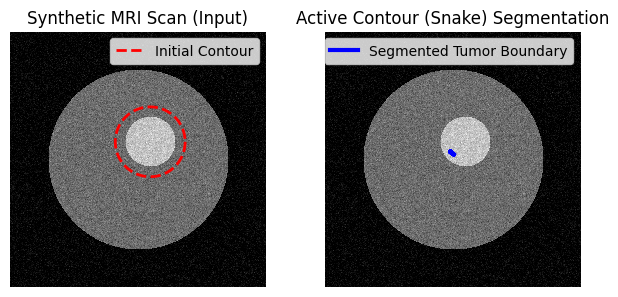

In [72]:
synthetic_brain = np.zeros((256, 256))
y, x = np.ogrid[:256, :256]
brain_mask = ((x - 128) ** 2 + (y - 128) ** 2) < 90 ** 2
synthetic_brain[brain_mask] = 100
tumor_mask = ((x - 140) ** 2 + (y - 110) ** 2) < 25 ** 2
synthetic_brain[tumor_mask] = 180
np.random.seed(42)
noise = np.random.normal(0, 15, synthetic_brain.shape)
synthetic_mri = np.clip(synthetic_brain + noise, 0, 255).astype(np.uint8)
smoothed_mri = gaussian(synthetic_mri, sigma=3)
theta = np.linspace(0, 2 * np.pi, 100)
x_init = 140 + 35 * np.cos(theta)
y_init = 110 + 35 * np.sin(theta)
init_contour = np.array([x_init, y_init]).T
snake_contour = active_contour(smoothed_mri, init_contour, alpha=0.015, beta=10, gamma=0.001)
fig, axes = plt.subplots(1, 2, figsize=(6, 5))
axes[0].imshow(synthetic_mri, cmap='gray')
axes[0].plot(init_contour[:, 0], init_contour[:, 1], '--r', lw=2, label='Initial Contour')
axes[0].set_title('Synthetic MRI Scan (Input)')
axes[0].legend(loc='upper right')
axes[0].axis('off')
axes[1].imshow(synthetic_mri, cmap='gray')
axes[1].plot(snake_contour[:, 0], snake_contour[:, 1], '-b', lw=3, label='Segmented Tumor Boundary')
axes[1].set_title('Active Contour (Snake) Segmentation')
axes[1].legend(loc='upper right')
axes[1].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)

9. Create a license-plate or text -region segmentation tool that isolates text areas from vehicle or document images.

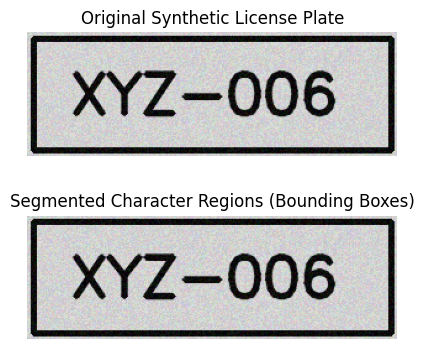

In [63]:
plate_img = np.ones((100, 300, 3), dtype=np.uint8) * 220
cv2.rectangle(plate_img, (5, 5), (295, 95), (0, 0, 0), 3)
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(plate_img, 'XYZ-006', (35, 65), font, 1.5, (0, 0, 0), 4, cv2.LINE_AA)
np.random.seed(12)
noise_plate = np.random.normal(0, 10, plate_img.shape).astype(np.uint8)
plate_noisy = cv2.addWeighted(plate_img, 0.9, noise_plate, 0.1, 0)
gray_plate = cv2.cvtColor(plate_noisy, cv2.COLOR_BGR2GRAY)
_, plate_bin = cv2.threshold(gray_plate, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
plate_opened = cv2.morphologyEx(plate_bin, cv2.MORPH_OPEN, kernel)
contours, _ = cv2.findContours(plate_opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output_plate = plate_noisy.copy()
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = w / float(h)
    area = w * h
    if 0.2 < aspect_ratio < 1.0 and 200 < area < 4000:
        cv2.rectangle(output_plate, (x, y), (x + w, y + h), (0, 255, 0), 2)
fig, axes = plt.subplots(2, 1, figsize=(4, 4))
axes[0].imshow(cv2.cvtColor(plate_noisy, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Synthetic License Plate')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(output_plate, cv2.COLOR_BGR2RGB))
axes[1].set_title('Segmented Character Regions (Bounding Boxes)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)

10. Build an evalution dashboard that compares segmentation accuracy(IoU or Dice score) of different methods against ground-truth masks.

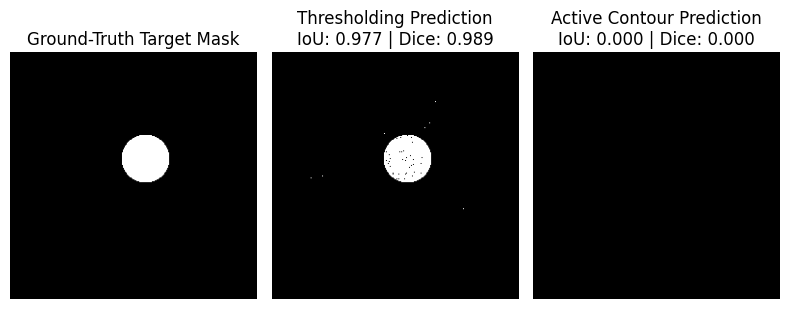

In [67]:
def calculate_iou(mask_pred, mask_true):
    intersection = np.logical_and(mask_pred, mask_true).sum()
    union = np.logical_or(mask_pred, mask_true).sum()
    if union == 0:
        return 1.0
    return intersection / union
def calculate_dice(mask_pred, mask_true):
    intersection = np.logical_and(mask_pred, mask_true).sum()
    total_pixels = mask_pred.sum() + mask_true.sum()
    if total_pixels == 0:
        return 1.0
    return (2. * intersection) / total_pixels
gt_mask = tumor_mask.astype(np.uint8)
pred_thresh = (synthetic_mri > 150).astype(np.uint8)
from skimage.draw import polygon
pred_snake = np.zeros_like(gt_mask)
rr, cc = polygon(snake_contour[:, 1], snake_contour[:, 0], shape=gt_mask.shape)
pred_snake[rr, cc] = 1
iou_thresh = calculate_iou(pred_thresh, gt_mask)
dice_thresh = calculate_dice(pred_thresh, gt_mask)
iou_snake = calculate_iou(pred_snake, gt_mask)
dice_snake = calculate_dice(pred_snake, gt_mask)
fig, axes = plt.subplots(1, 3, figsize=(8, 5))
axes[0].imshow(gt_mask, cmap='gray')
axes[0].set_title('Ground-Truth Target Mask')
axes[0].axis('off')
axes[1].imshow(pred_thresh, cmap='gray')
axes[1].set_title(f"Thresholding Prediction\nIoU: {iou_thresh:.3f} | Dice: {dice_thresh:.3f}")
axes[1].axis('off')
axes[2].imshow(pred_snake, cmap='gray')
axes[2].set_title(f"Active Contour Prediction\nIoU: {iou_snake:.3f} | Dice: {dice_snake:.3f}")
axes[2].axis('off')
plt.tight_layout()
plt.show()
#Priyashi(39)